In [3]:

import os
import sys

import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

# Add the head direcoty to sys.path
workspace_root = "/exp/sbnd/app/users/amoor/cafpyana/cafpyana/analysis_village/sample_validations/202503"  
sys.path.insert(0, workspace_root + "/../../../")

# import this repo's classes
import pyanalib.pandas_helpers as ph
from makedf.util import *

#import dunestyle.matplotlib as dunestyle

In [4]:
venv_path = os.getenv("PATH")

In [5]:
venv_path

'/opt/conda/bin:/opt/conda/condabin:/opt/conda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/sbin'

In [6]:
input_path = "/exp/sbnd/data/users/sungbino/sbnd_samples/cafpyana_outputs/"
mc_file = input_path + "Spring25Dev_MC_bnb_cosmics.df"
data_file = input_path + "Spring25Dev_data.df"

In [7]:
mc_hdr_df = pd.read_hdf(mc_file, key='hdr')
mc_evt_df = pd.read_hdf(mc_file, key='evt')
mc_nu_df = pd.read_hdf(mc_file, key='mcnu')

data_hdr_df = pd.read_hdf(data_file, key='hdr')
data_evt_df = pd.read_hdf(data_file, key='evt')

In [8]:

mc_hdr_df

,pot,first_in_subrun,ismc,run,subrun,ngenevt,evt,proc,cluster,fno
entry,,,,,,,,,,
0,1.595585e+15,1,1,7,99,100,1,0,61660523,0
1,0.000000e+00,0,1,7,99,100,2,0,61660523,0
2,0.000000e+00,0,1,7,99,100,3,0,61660523,0
3,0.000000e+00,0,1,7,99,100,5,0,61660523,0
4,0.000000e+00,0,1,7,99,100,6,0,61660523,0
...,...,...,...,...,...,...,...,...,...,...
266159,0.000000e+00,0,1,91,44,100,78,0,61660605,14
266160,0.000000e+00,0,1,91,44,100,81,0,61660605,14
266161,0.000000e+00,0,1,91,44,100,92,0,61660605,14


In [9]:
data_hdr_df

,pot,first_in_subrun,ismc,run,subrun,ngenevt,evt,proc,cluster,fno
entry,,,,,,,,,,
0,0.0,1,0,18255,1,0,431147,0,75824387,0
1,0.0,0,0,18255,1,0,431169,0,75824387,0
2,0.0,0,0,18255,1,0,431587,0,75824387,0
3,0.0,0,0,18255,1,0,431697,0,75824387,0
4,0.0,0,0,18255,1,0,432005,0,75824387,0
...,...,...,...,...,...,...,...,...,...,...
94052,0.0,0,0,18255,1,0,243744,0,75829972,0
94053,0.0,0,0,18255,1,0,244162,0,75829972,0
94054,0.0,0,0,18255,1,0,244316,0,75829972,0


In [10]:
mc_tot_pot = mc_hdr_df['pot'].sum()
data_tot_pot = data_hdr_df['pot'].sum()

print("mc_tot_pot: %e, data_tot_pot: %e" %(mc_tot_pot, data_tot_pot))

mc_tot_pot: 2.292707e+19, data_tot_pot: 0.000000e+00


In [11]:
mc_nu_df

E      time  bjorkenX inelasticityY        Q2  \
                                                                                
                                                                                
entry  rec.mc.nu..index                                                         
0      0                 0.507817  0.722970  0.732417      0.339503  0.237120   
1      0                 0.591333  0.562440  0.239762      0.761234  0.202669   
       1                 2.576564  0.546826  0.518944      0.355246  0.891965   
       2                 0.604625  0.696956  0.219819      0.681803  0.170164   
2      0                 1.029089  1.568090  0.493424      0.580822  0.553827   
...                           ...       ...       ...           ...       ...   
266162 0                 4.496964  0.780902  0.157204      0.694606  0.922102   
       1                 1.645866  0.838732  0.428208      0.632764  0.837430   
       2                 1.629440  1.147930  1.072275      0.164396  0.539378   
266163 0                 0.779944  0.401203  0.111972      0.266801  0.043754   
       1                 3.999120  0.513477  0.105572      0.111730  0.088580   

                                w  momentum                        position  \
                                          x         y         z           x   
                                                                              
entry  rec.mc.nu..index                                                       
0      0                 0.983971  0.012148  0.003621  0.507659  185.291595   
1      0                 1.234582  0.019384 -0.018232  0.590734  140.366135   
       1                 1.307062 -0.067310 -0.159771  2.570724 -270.725250   
       2                 1.218817  0.005703 -0.009210  0.604528   21.591654   
2      0                 1.204225 -0.006911  0.000437  1.029066 -126.629738   
...                           ...       ...       ...       ...         ...   
266162 0                 2.413527 -0.013454 -0.049713  4.496668  -72.879890   
       1                 1.414143 -0.026879 -0.006252  1.645635 -223.629181   
       2                 0.919354  0.043639 -0.003594  1.628851  220.854935   
266163 0                 1.108410 -0.036623  0.013286  0.778970 -597.091919   
       1                 1.277515 -0.061435 -0.010467  3.998634 -200.437729   

                         ...         p                                   \
                         ...      genp                            start   
                         ...         x         y         z            x   
entry  rec.mc.nu..index  ...                                              
0      0                 ...  0.000878 -0.285483  0.427427   185.291595   
1      0                 ...  0.138556  0.019950  0.781721   140.366135   
       1                 ...       NaN       NaN       NaN          NaN   
       2                 ...       NaN       NaN       NaN          NaN   
2      0                 ...  0.040925  0.055383  0.172846  -126.629738   
...                      ...       ...       ...       ...          ...   
266162 0                 ...       NaN       NaN       NaN          NaN   
       1                 ...  0.320015  0.377301  0.886702 -9999.000000   
       2                 ...  0.107885  0.062955  0.037640 -9999.000000   
266163 0                 ...       NaN       NaN       NaN          NaN   
       1                 ...  0.054269  0.286677 -0.000514  -200.437729   

                                                                             \
                                                           end                
                                   y            z            x            y   
entry  rec.mc.nu..index                                                       
0      0                   62.526066   458.182037   185.643097    57.374458   
1      0                 -201.415497   162.773087   143.804337  -201.330002   
       1                      

In [12]:


mc_nu_df.columns



MultiIndex([(            'E',       '',  ''),
            (         'time',       '',  ''),
            (     'bjorkenX',       '',  ''),
            ('inelasticityY',       '',  ''),
            (           'Q2',       '',  ''),
            (            'w',       '',  ''),
            (     'momentum',      'x',  ''),
            (     'momentum',      'y',  ''),
            (     'momentum',      'z',  ''),
            (     'position',      'x',  ''),
            (     'position',      'y',  ''),
            (     'position',      'z',  ''),
            (          'pdg',       '',  ''),
            (         'iscc',       '',  ''),
            (   'genie_mode',       '',  ''),
            (   'parent_pdg',       '',  ''),
            ( 'parent_dcy_E',       '',  ''),
            ('max_proton_ke',       '',  ''),
            (           'nn',       '',  ''),
            (           'np',       '',  ''),
            (          'nmu',       '',  ''),
            (          'npi',     

In [13]:
is_fv = InFV(mc_nu_df.position, 0, 0, 0, 0, "SBND")
is_cc = mc_nu_df.iscc
genie_mode = mc_nu_df.genie_mode
nuint_categ = pd.Series(8, index=mc_nu_df.index)
nuint_categ[~is_fv] = -1  # Out of FV
nuint_categ[is_fv & ~is_cc] = 0  # NC
nuint_categ[is_fv & is_cc & (genie_mode == 3)] = 1  # CCCOH
nuint_categ[is_fv & is_cc & (genie_mode == 0)] = 2  # CCQE
nuint_categ[is_fv & is_cc & (genie_mode == 10)] = 3  # 2p2h
nuint_categ[is_fv & is_cc & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & (genie_mode == 1)] = 4  # RES
nuint_categ[is_fv & is_cc & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & (genie_mode == 2)] = 5  # DIS

In [14]:
mc_nu_df['nuint_categ'] = nuint_categ

In [15]:
mc_evt_df

slc              \
                                              is_clear_cosmic      vertex   
                                                                        x   
                                                                            
                                                                            
                                                                            
entry  rec.slc..index rec.slc.reco.pfp..index                               
0      0              0                                     0  110.683205   
       1              0                                     0  100.009987   
       2              0                                     0  146.425049   
       3              0                                     0   54.088589   
       4              0                                     1   12.458182   
..                                                        ...         ...   
266149 6              0                                     1  114.070961   
                      1                                     1  114.070961   
       7              0                                     1  233.709167   
                      1                                     1  233.709167   
                      3                                     1  233.709167   

                                                                            \
                                                                      self   
                                                        y           z        
                                                                             
                                                                             
                                                                             
entry  rec.slc..index rec.slc.reco.pfp..index                                
0      0              0                        130.374283   47.625019   43   
       1              0                        126.116615  266.322968   44   
       2              0                        162.759933  218.392838   42   
       3              0                        193.312210    3.932156   41   
       4              0                        199.989441  248.546127    0   
..                                                    ...         ...  ...   
266149 6              0                        200.724365  400.454681    4   
                      1                        200.724365  400.454681    4   
       7              0                       -152.705566  234.764343    6   
                      1                       -152.705566  234.764343    6   
                      3                       -152.705566  234.764343    6   

                                                                        \
                                              tmatch          producer   
                                                 eff pur  idx            
                                                                         
                                                                         
                                                                         
entry  rec.slc..index rec.slc.reco.pfp..index                            
0      0              0                          NaN NaN -999        0   
       1              0                          NaN NaN -999        0   
       2              0                          NaN NaN -999        0   
       3              0                          NaN NaN -999        0   
       4              0                          NaN NaN -999        0   
..                                               ...  ..  ...      ...   
266149 6              0                          NaN NaN -999        0   
                      1                          NaN NaN -999        0   
       7              0                          NaN NaN -999        0   
                      1                          NaN NaN -999        0   
        

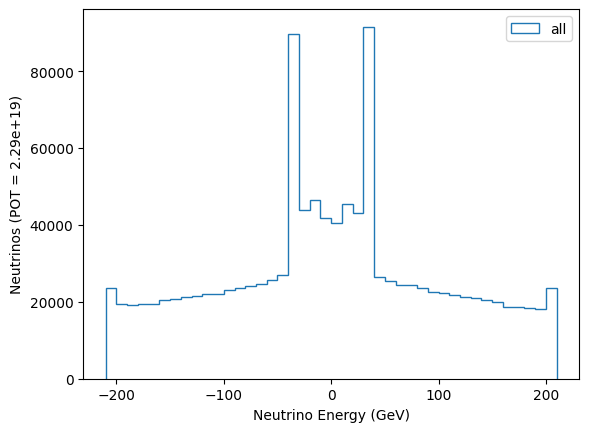

In [16]:
var = data_evt_df.slc.vertex.x 
plt.hist(var, bins=np.linspace(-210., 210., 43), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

In [17]:
data_evt_df

slc              \
                                             is_clear_cosmic      vertex   
                                                                       x   
                                                                           
                                                                           
                                                                           
entry rec.slc..index rec.slc.reco.pfp..index                               
0     0              1                                     0  -99.640762   
                     2                                     0  -99.640762   
      1              9                                     1  -21.288662   
      2              3                                     1   86.256706   
                     6                                     1   86.256706   
..                                                       ...         ...   
94049 3              5                                     1  204.545410   
                     11                                    1  204.545410   
      4              0                                     1   69.701790   
                     1                                     1   69.701790   
      5              1                                     1   29.361826   

                                                                           \
                                                                     self   
                                                       y           z        
                                                                            
                                                                            
                                                                            
entry rec.slc..index rec.slc.reco.pfp..index                                
0     0              1                        159.892181  190.661697   59   
                     2                        159.892181  190.661697   59   
      1              9                        199.893936  294.383850    1   
      2              3                        107.426254  254.114487    2   
                     6                        107.426254  254.114487    2   
..                                                   ...         ...  ...   
94049 3              5                         -1.716485   98.973061    2   
                     11                        -1.716485   98.973061    2   
      4              0                       -128.816101  158.284470    4   
                     1                       -128.816101  158.284470    4   
      5              1                        199.266098  316.703705    9   

                                                                       \
                                             tmatch          producer   
                                                eff pur  idx            
                                                                        
                                                                        
                                                                        
entry rec.slc..index rec.slc.reco.pfp..index                            
0     0              1                          NaN NaN -999        0   
                     2                          NaN NaN -999        0   
      1              9                          NaN NaN -999        0   
      2              3                          NaN NaN -999        0   
                     6                          NaN NaN -999        0   
..                                              ...  ..  ...      ...   
94049 3              5                          NaN NaN -999        0   
                     11                         NaN NaN -999        0   
      4              0                          NaN NaN -999        0   
                     1                          NaN NaN -999        0   
      5              1                          NaN NaN -999

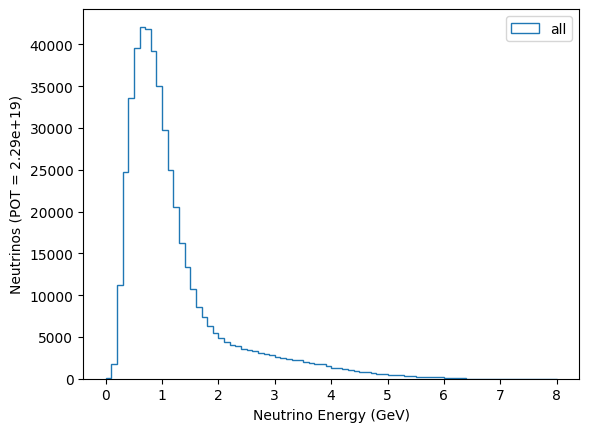

In [18]:
# True nu variables

## 1) nu.E
var = mc_nu_df.E 
plt.hist(var, bins=np.linspace(0., 8., 81), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

In [19]:
mc_matchdf = ph.multicol_merge(mc_evt_df.reset_index(), mc_nu_df.reset_index(),
                            left_on=[("entry", "",""), ("slc","tmatch", "idx", "", "", "")],
                            right_on=[("entry", "",""), ("rec.mc.nu..index", "","")], 
                            how="left") ## -- save all sllices

/exp/sbnd/app/users/amoor/cafpyana/cafpyana/analysis_village/sample_validations/202503/../../../pyanalib/pandas_helpers.py:85: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


In [20]:
mc_matchdf

entry rec.slc..index rec.slc.reco.pfp..index             slc  \
                                                       is_clear_cosmic   
                                                                         
                                                                         
                                                                         
                                                                         
0             0              0                       0               0   
1             0              1                       0               0   
2             0              2                       0               0   
3             0              3                       0               0   
4             0              4                       0               1   
..          ...            ...                     ...             ...   
3350926  266149              6                       0               1   
3350927  266149              6                       1               1   
3350928  266149              7                       0               1   
3350929  266149              7                       1               1   
3350930  266149              7                       3               1   

                                                             ...    p      \
             vertex                         self tmatch      ... genp       
                  x           y           z         eff pur  ...    y   z   
                                                             ...            
                                                             ...            
                                                             ...            
0        110.683205  130.374283   47.625019   43    NaN NaN  ...  NaN NaN   
1        100.009987  126.116615  266.322968   44    NaN NaN  ...  NaN NaN   
2        146.425049  162.759933  218.392838   42    NaN NaN  ...  NaN NaN   
3         54.088589  193.312210    3.932156   41    NaN NaN  ...  NaN NaN   
4         12.458182  199.989441  248.546127    0    NaN NaN  ...  NaN NaN   
..              ...         ...         ...  ...    ...  ..  ...  ...  ..   
3350926  114.070961  200.724365  400.454681    4    NaN NaN  ...  NaN NaN   
3350927  114.070961  200.724365  400.454681    4    NaN NaN  ...  NaN NaN   
3350928  233.709167 -152.705566  234.764343    6    NaN NaN  ...  NaN NaN   
3350929  233.709167 -152.705566  234.764343    6    NaN NaN  ...  NaN NaN   
3350930  233.709167 -152.705566  234.764343    6    NaN NaN  ...  NaN NaN   

                                  ind nuint_categ  
        start         end                          
            x   y   z   x   y   z                  
                                                   
                                                   
                                                   
0         NaN NaN NaN NaN NaN NaN NaN         NaN  
1         NaN NaN NaN NaN NaN NaN NaN         NaN  
2         NaN NaN NaN NaN NaN NaN NaN         NaN  
3         NaN NaN NaN NaN NaN NaN NaN         NaN  
4         NaN NaN NaN NaN NaN NaN NaN         NaN  
..        ...  ..  ..  ..  ..  ..  ..         ...  
3350926   NaN NaN NaN NaN NaN NaN NaN         NaN  
3350927   NaN NaN NaN NaN NaN NaN NaN         NaN  
3350928   NaN NaN NaN NaN NaN NaN NaN         NaN  
3350929   NaN NaN NaN NaN NaN NaN NaN         NaN  
3350930   NaN NaN NaN NaN NaN NaN NaN         NaN  

[3350931 rows x 216 columns]

In [21]:
## -- Make unmatched slice to have nuint_categ = -2
notmatcheddf = mc_matchdf[pd.isna(mc_matchdf.nuint_categ)]
matcheddf = mc_matchdf[~pd.isna(mc_matchdf.nuint_categ)]
notmatcheddf.nuint_categ = -2
mc_matchdf = pd.concat([matcheddf, notmatcheddf])

/tmp/ipykernel_1515/2465534872.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  notmatcheddf.nuint_categ = -2


In [22]:
mc_matchdf = mc_matchdf.set_index(['entry', 'rec.slc..index', 'rec.slc.reco.pfp..index'])

In [23]:
mc_matchdf

slc              \
                                              is_clear_cosmic      vertex   
                                                                        x   
                                                                            
                                                                            
                                                                            
entry  rec.slc..index rec.slc.reco.pfp..index                               
1      0              0                                     0  148.063217   
2      1              0                                     0 -126.616188   
                      1                                     0 -126.616188   
3      7              0                                     1 -104.502151   
                      1                                     1 -104.502151   
..                                                        ...         ...   
266149 6              0                                     1  114.070961   
                      1                                     1  114.070961   
       7              0                                     1  233.709167   
                      1                                     1  233.709167   
                      3                                     1  233.709167   

                                                                            \
                                                                      self   
                                                        y           z        
                                                                             
                                                                             
                                                                             
entry  rec.slc..index rec.slc.reco.pfp..index                                
1      0              0                       -200.353958  184.310471   21   
2      1              0                         21.935757  225.116440   51   
                      1                         21.935757  225.116440   51   
3      7              0                        -82.142075   25.935946    4   
                      1                        -82.142075   25.935946    4   
..                                                    ...         ...  ...   
266149 6              0                        200.724365  400.454681    4   
                      1                        200.724365  400.454681    4   
       7              0                       -152.705566  234.764343    6   
                      1                       -152.705566  234.764343    6   
                      3                       -152.705566  234.764343    6   

                                                                        \
                                                 tmatch                  
                                                    eff       pur  idx   
                                                                         
                                                                         
                                                                         
entry  rec.slc..index rec.slc.reco.pfp..index                            
1      0              0                        0.833902  0.819453    0   
2      1              0                        0.800736  0.995006    0   
                      1                        0.800736  0.995006    0   
3      7              0                        0.760536  0.966144    1   
                      1                        0.760536  0.966144    1   
..                                                  ...       ...  ...   
266149 6              0                             NaN       NaN -999   
                      1                             NaN       NaN -999   
       7              0                             NaN       NaN -999   
                      1                             NaN       NaN -999   
        

In [24]:
## -- Label definitions for plotting
mode_list = [1, 0, 4, 5, 3, 2, -1, -2]
mode_labels = ["CC COH", "NC", "CC RES", "CC IDS", "CC 2p2h", "CC QE", "Non-FV", "Others"]
colors = [#'#d62728',  # Red            
          '#1f77b4',  # Blue
          '#ff7f0e',  # Orange
          '#2ca02c',  # Green
          '#17becf',  # Teal
          '#9467bd',  # Purple
          '#8c564b',  # Brown
          '#e377c2',  # Pink
          '#7f7f7f']  # Gray
          #'#bcbd22',  # Yellow-green
          #'#17becf']  # Teal

def draw_reco_stacked_hist(var, is_logy, title_x, title_y, x_min, x_max, nbins, outname, data_overlay = False, var_data = []):
    plt.figure(figsize=(800/100, 600/100), dpi=100)
    POT_scale = 1.
    # No data overlay — keep original logic
    hist_data, bins, _ = plt.hist(var,
                                    bins=np.linspace(x_min, x_max, nbins + 1),
                                    weights=[np.ones_like(data) * POT_scale for data in var],
                                    stacked=True,
                                    color=colors,
                                    label=mode_labels,
                                    edgecolor='none',
                                    linewidth=0,
                                    density=data_overlay,
                                histtype='stepfilled')
    max_y = np.max([np.sum(vals) for vals in zip(*hist_data)])
    print(max_y)
    plt.xlim(x_min, x_max)
    plt.ylim(0.0, max_y * 1.5)
    plt.xlabel(title_x)
    plt.ylabel(title_y)
    if is_logy:
        plt.ylim(0.1, max_y * 600)
        plt.yscale('log')
    
    if data_overlay:
        plt.ylabel("A.U.")
        # Normalize data by area
        counts, _ = np.histogram(var_data, bins=np.linspace(x_min, x_max, nbins + 1))
        bin_widths = np.diff(np.linspace(x_min, x_max, nbins + 1))
        total_data = np.sum(counts)
        norm_counts = counts / (total_data * bin_widths)
        errors = np.sqrt(counts) / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)
        bin_centers = 0.5 * (np.linspace(x_min, x_max, nbins + 1)[:-1] + np.linspace(x_min, x_max, nbins + 1)[1:])

        # -- non-zero mask
        nonzero_mask = counts > 0
        bin_centers = bin_centers[nonzero_mask]
        norm_counts = norm_counts[nonzero_mask]
        errors = errors[nonzero_mask]
        
        # Plot data with error bars
        plt.errorbar(bin_centers, norm_counts, yerr=errors,
                     fmt='o', color='black', label='Data',
                     markersize=5, capsize=3, linewidth=1.5)


    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(width=2, length=10)

    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    print(total_sum)
    individual_sums = [accum_sum[i+1] - accum_sum[i] for i in range(len(accum_sum) - 1)]
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]
    if data_overlay:
        legend_labels.append("Data")
    colors_reversed = colors[::-1]  # Ensure colors match reversed labels
    plt.legend(legend_labels, loc='upper left', fontsize=11, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))
    
    plt.text(0.00, 1.02, "SBND Sample (2025A Dev.), Preliminary", transform=plt.gca().transAxes,
             fontsize = 14, fontweight = 'bold')
    #plt.savefig("../output/plots/reco_slc/" + outname + ".pdf", format='pdf')
    plt.show()

In [25]:
def draw_mc_data_shape_comp_per_slc(mc_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name):
    nuint_categ_col = ('nuint_categ', '', '', '', '', '')
    mc_df_per_slc = mc_df.groupby([('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_df_per_slc = data_df.groupby([('entry'), ('rec.slc..index')])[[column]].first()
    var_mc = [mc_df_per_slc[mc_df_per_slc.nuint_categ == mode][column] for mode in mode_list]
    var_data = data_df_per_slc[column]
    draw_reco_stacked_hist(var_mc, False, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data)

In [26]:
def draw_reco_valid_plots(mc_df, data_df, suffix):
    ## draw 1) clear cosmic, 2) nu score, 3) vertex x,y and z
    
    ## -- 1) Clear cosmic
    clear_cosmic_col = ('slc', 'is_clear_cosmic', '', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, clear_cosmic_col, "Is Clear Cosmic", "A.U.", -0.5, 1.5, 2, suffix + "_slc_is_clear_cosmic")

    ## -- 2) nu score
    nu_score_col = ('slc', 'nu_score', '', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, nu_score_col, "Nu Score", "A.U.", -1.1, 1.1, 44, suffix + "_slc_nu_score")

    ## -- 3) vertex x,y,z
    vtx_x_col = ('slc', 'vertex', 'x', '', '', '')
    vtx_y_col = ('slc', 'vertex', 'y', '', '', '')
    vtx_z_col = ('slc', 'vertex', 'z', '', '', '')
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_x_col, "Slice Vertex X [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_x")
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_y_col, "Slice Vertex Y [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_y")
    draw_mc_data_shape_comp_per_slc(mc_df, data_df, vtx_z_col, "Slice Vertex Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_vtx_z")

    



0.748558729481276
1.0


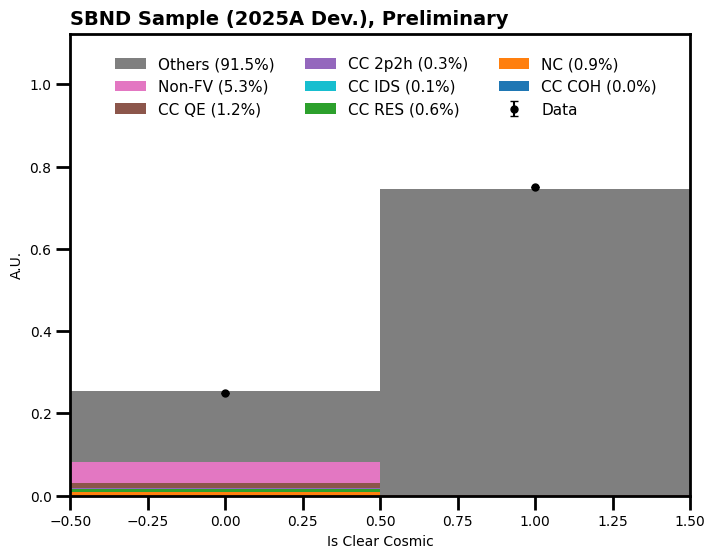

14.971349642724979
20.00000000000002


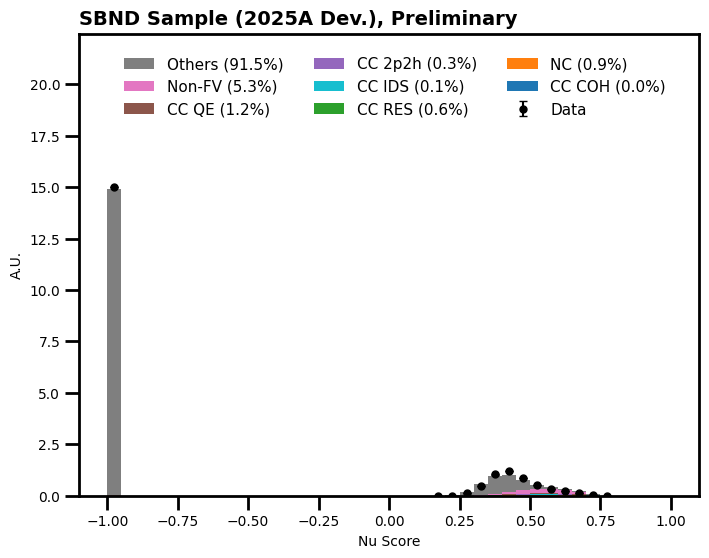

0.011076693263623297
0.16666666666666669


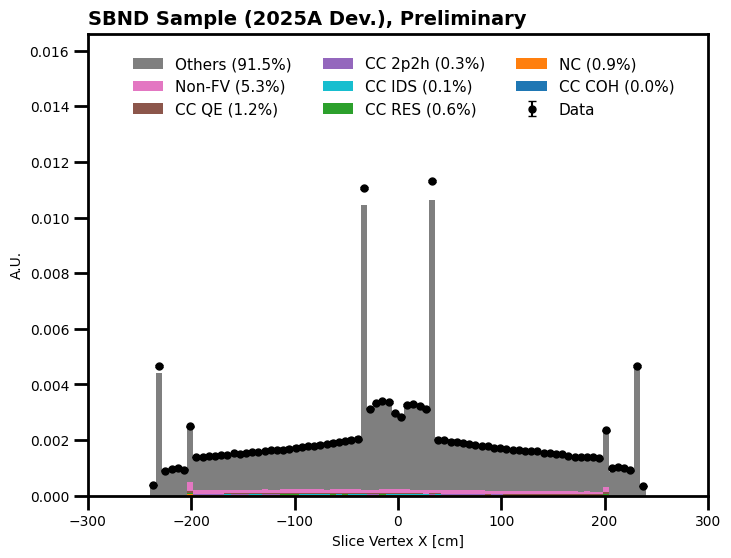

0.06118737181629964
0.16666666666666669


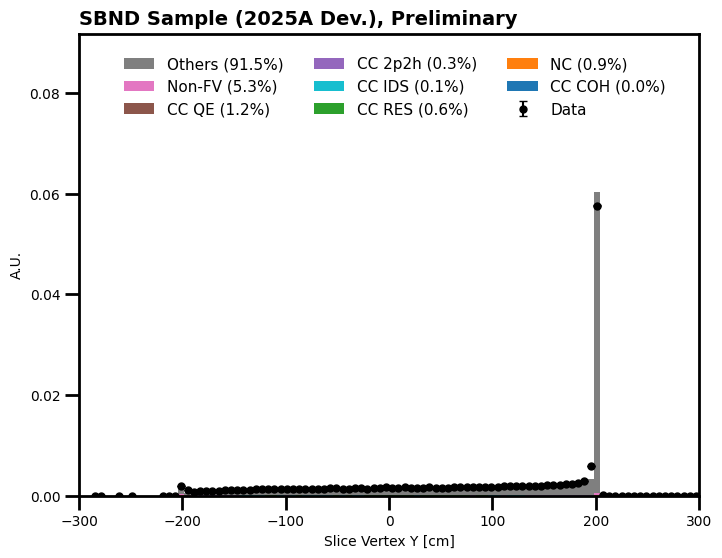

0.01438869268049576
0.14285714285714282


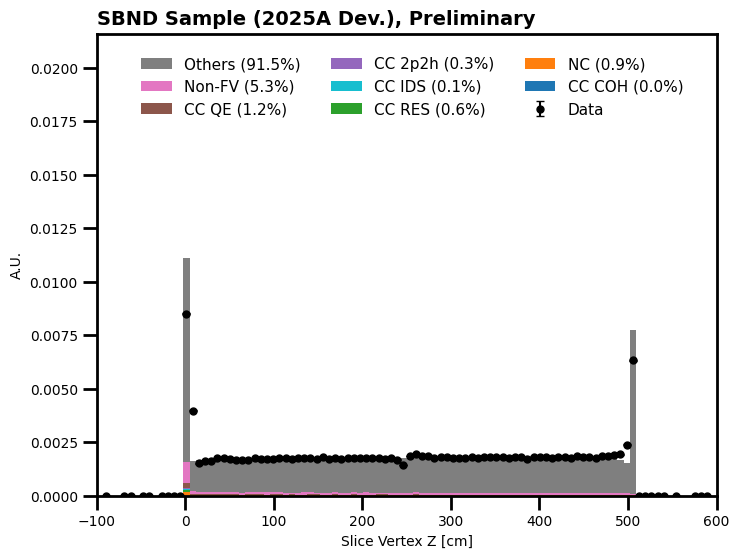

In [27]:
## Reco 1) Nocut
draw_reco_valid_plots(mc_matchdf, data_evt_df, "nocut")

0.7091149266850454
1.0


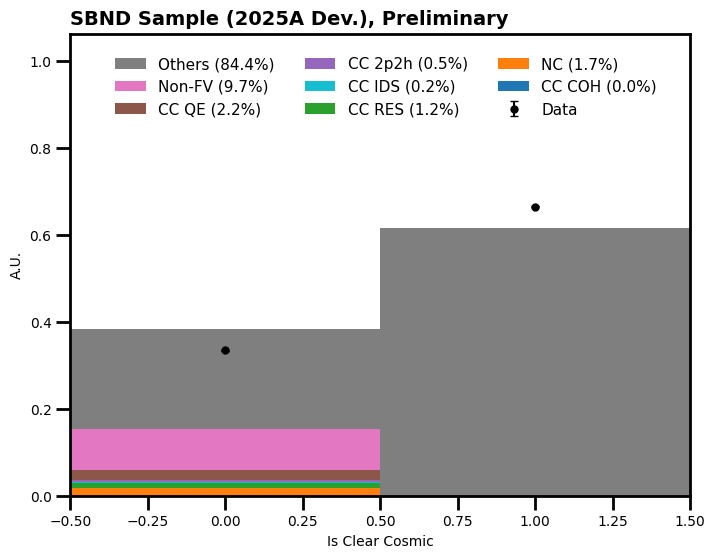

12.393598425826058
20.000000000000014


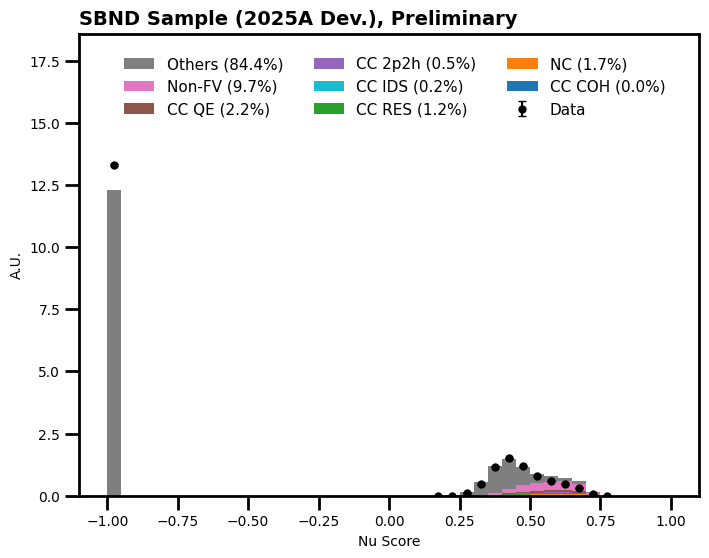

0.023528332134723717
0.16666666666666666


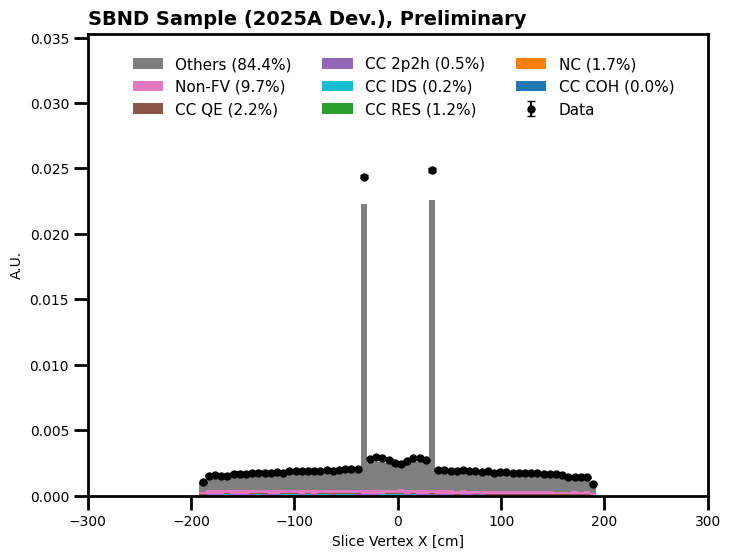

0.0049627848362566096
0.16666666666666666


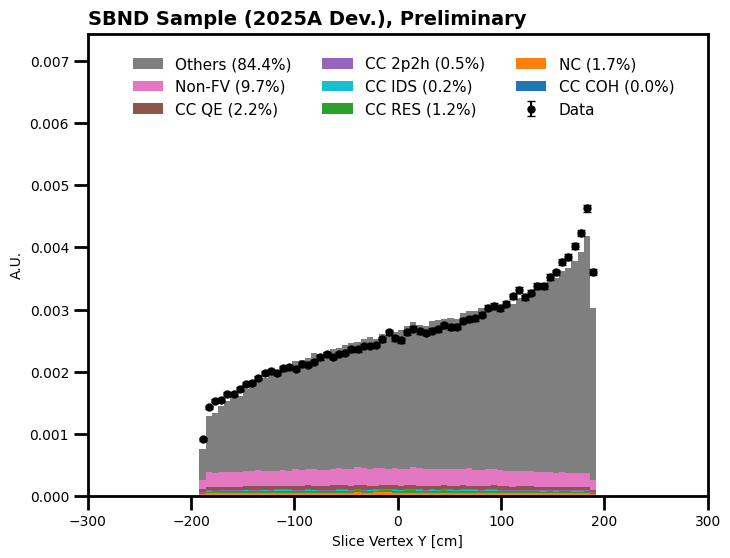

0.003217339314966068
0.14285714285714285


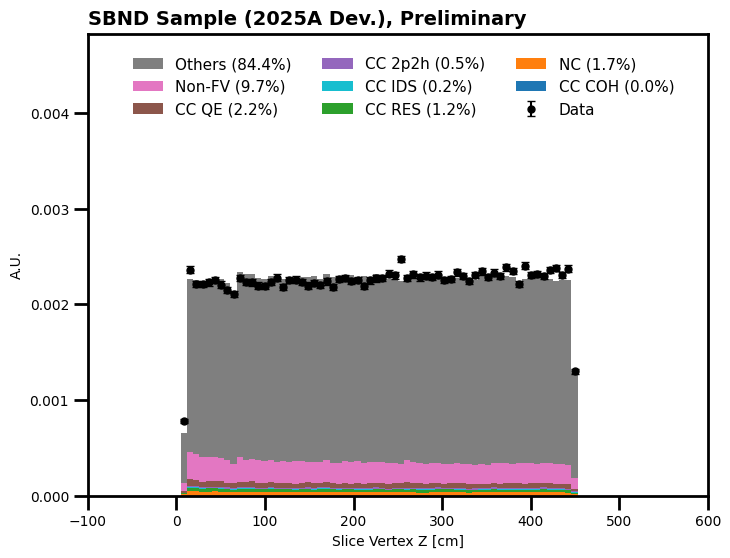

In [28]:
## Reco 2) FV cut
is_fv_mc = InFV(mc_matchdf.slc.vertex, 0, 0, 0, 0, "SBND")
is_fv_data = InFV(data_evt_df.slc.vertex, 0, 0, 0, 0, "SBND")

mc_matchdf = mc_matchdf[is_fv_mc]
data_evt_df = data_evt_df[is_fv_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "nocut")

1.8454434978132168
1.0


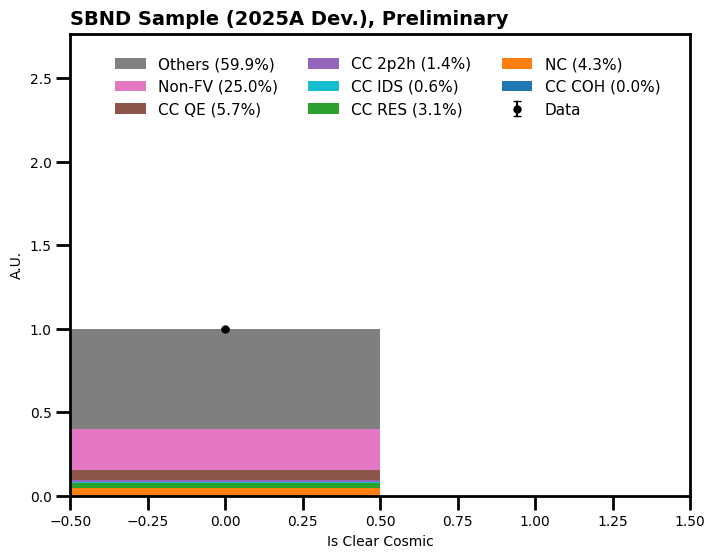

5.413994112257027
20.000000000000004


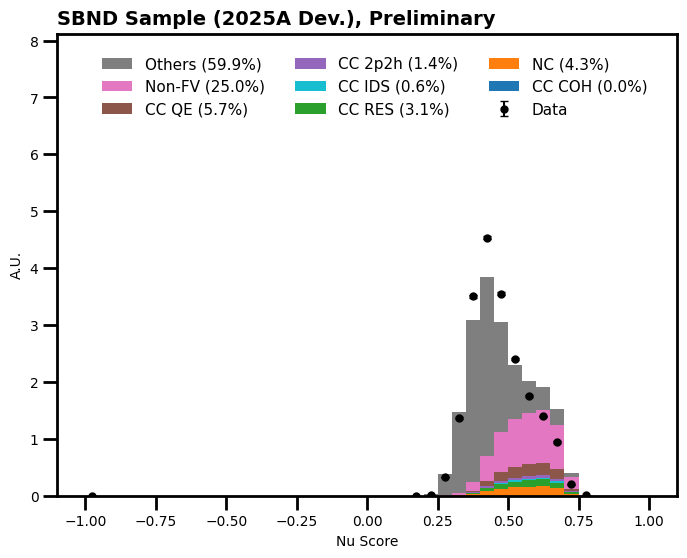

0.005514614296514361
0.16666666666666669


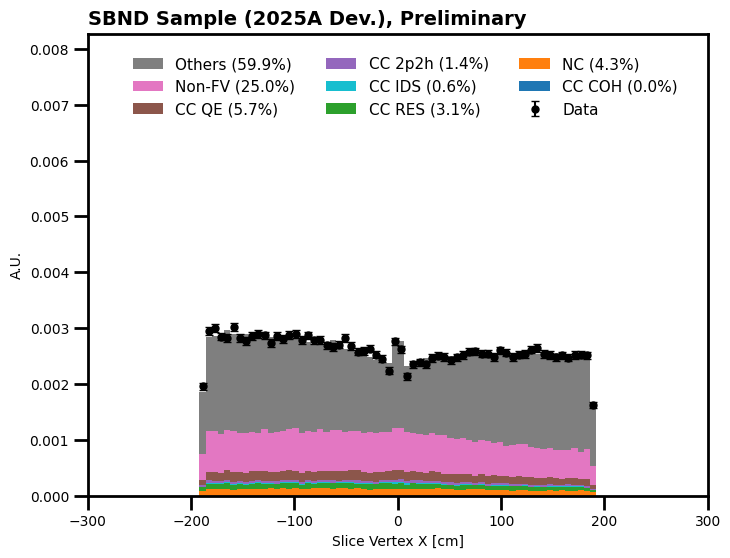

0.006773178926299236
0.16666666666666666


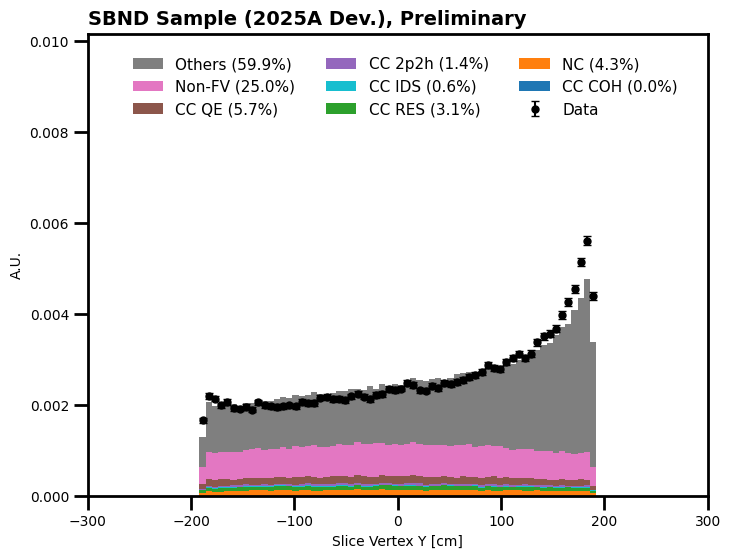

0.005372960015893749
0.14285714285714285


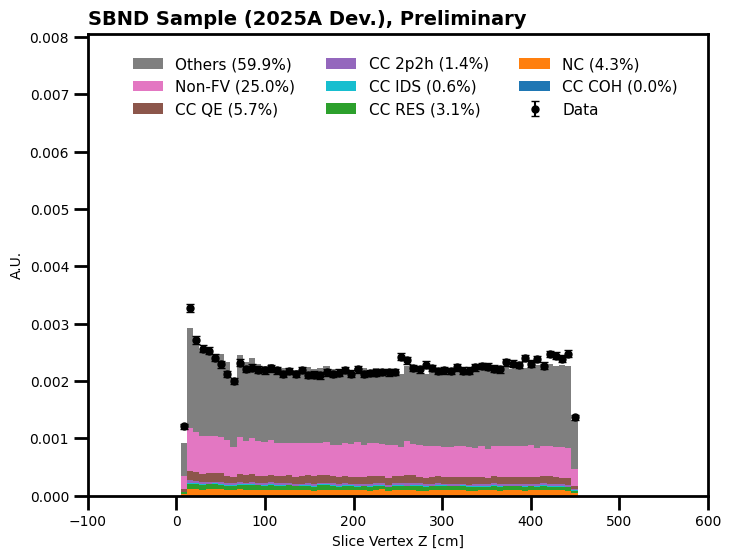

In [29]:
## Reco 3) !is_clear_cosmic
isnt_clear_cosmic_mc = (mc_matchdf.slc.is_clear_cosmic == 0)
isnt_clear_cosmic_data = (data_evt_df.slc.is_clear_cosmic == 0)

mc_matchdf = mc_matchdf[isnt_clear_cosmic_mc]
data_evt_df = data_evt_df[isnt_clear_cosmic_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "is_clear_cosmic")

In [30]:
def dist_pfptrk_vertex(df):
    this_vertex_x = df[('slc', 'vertex', 'x', '', '', '')]
    this_vertex_y = df[('slc', 'vertex', 'y', '', '', '')]
    this_vertex_z = df[('slc', 'vertex', 'z', '', '', '')]

    this_pfp_start_x = df[('pfp', 'trk', 'start', 'x', '', '')]
    this_pfp_start_y = df[('pfp', 'trk', 'start', 'y', '', '')]
    this_pfp_start_z = df[('pfp', 'trk', 'start', 'z', '', '')]

    this_dist = np.sqrt(
        (this_vertex_x - this_pfp_start_x) ** 2 +
        (this_vertex_y - this_pfp_start_y) ** 2 +
        (this_vertex_z - this_pfp_start_z) ** 2
    )

    return this_dist

def add_pfp_len_cut_multi_col(df, len_cut = 4., vtx_dist_cut = 6., n_trk_len_col = 'n_trk_4cm', n_trk_dist_col = 'n_trk_vtx_dist_6cm'):
    ## pfp trk len > 4 cm
    cut_trk_len = df.pfp.trk.len > len_cut
    n_trk_df = cut_trk_len.reset_index(name='len')
    all_combinations = (
        n_trk_df[['entry', 'rec.slc..index']].drop_duplicates().set_index(['entry', 'rec.slc..index'])
    )
    n_trk_df = (
        n_trk_df[n_trk_df['len'] == True]
        .groupby(['entry', 'rec.slc..index'])
        .size()
        .reindex(all_combinations.index, fill_value=0)
    )
    df[('rec', n_trk_len_col, '', '', '', '')] = n_trk_df


    ## and pfp trk vtx dist < 6 cm
    vtx_dist_df_series = dist_pfptrk_vertex(df)
    cut_vtx_dist = vtx_dist_df_series < vtx_dist_cut
    cut_vtx_dist = cut_vtx_dist & cut_trk_len
    n_vtx_dist_df = cut_vtx_dist.reset_index(name='len')

    all_combinations = (
        n_vtx_dist_df[['entry', 'rec.slc..index']].drop_duplicates().set_index(['entry', 'rec.slc..index'])
    )
    n_vtx_dist_df = (
        n_vtx_dist_df[n_vtx_dist_df['len'] == True]
        .groupby(['entry', 'rec.slc..index'])
        .size()
        .reindex(all_combinations.index, fill_value=0)
    )
    df[('rec', n_trk_dist_col, '', '', '', '')] = n_vtx_dist_df
    df[('pfp', 'trk', 'pass_vtx_dist', '', '', '')] = cut_vtx_dist

In [31]:
add_pfp_len_cut_multi_col(data_evt_df)
add_pfp_len_cut_multi_col(mc_matchdf)

2.0964011736605035
1.0


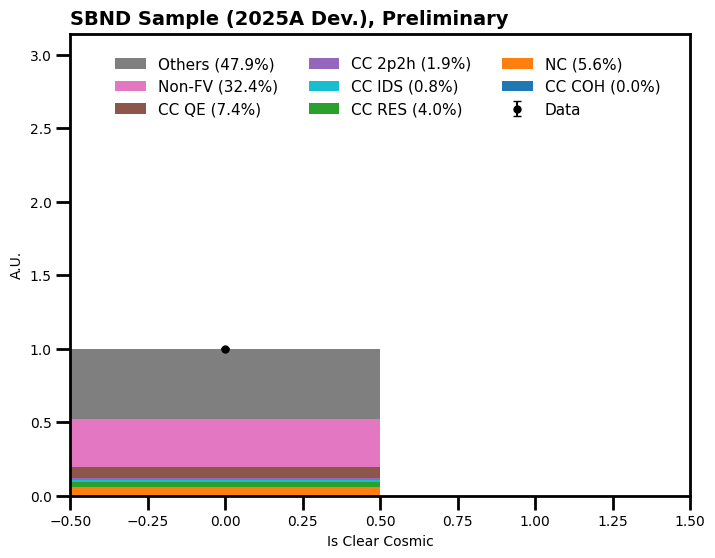

8.299190280707153
20.000000000000007


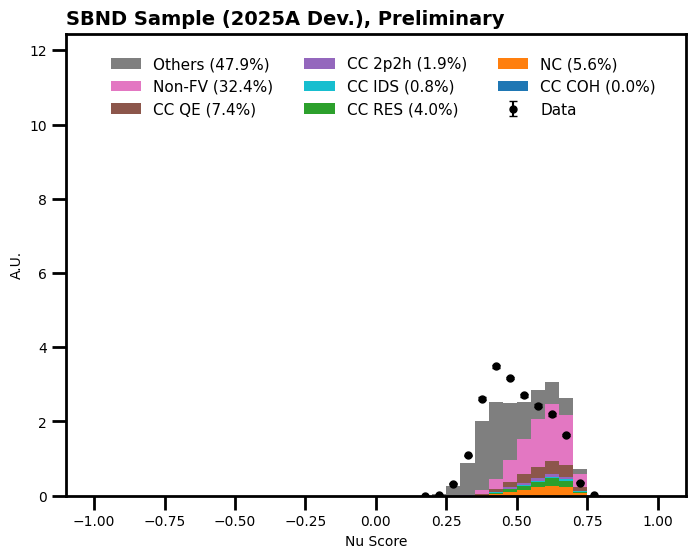

0.006383941343588447
0.16666666666666666


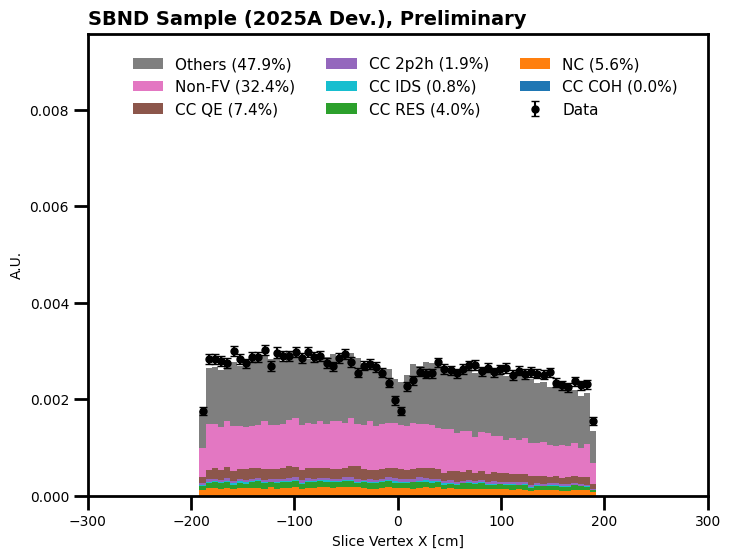

0.006563583257373635
0.16666666666666669


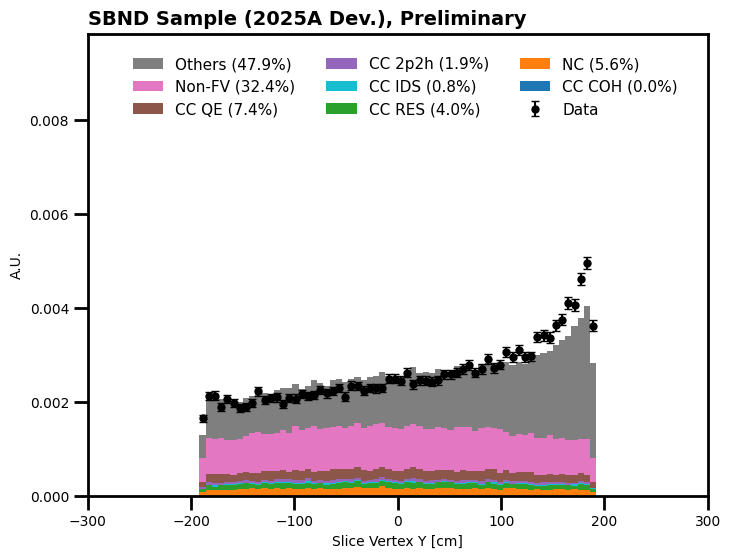

0.006384416586746608
0.14285714285714285


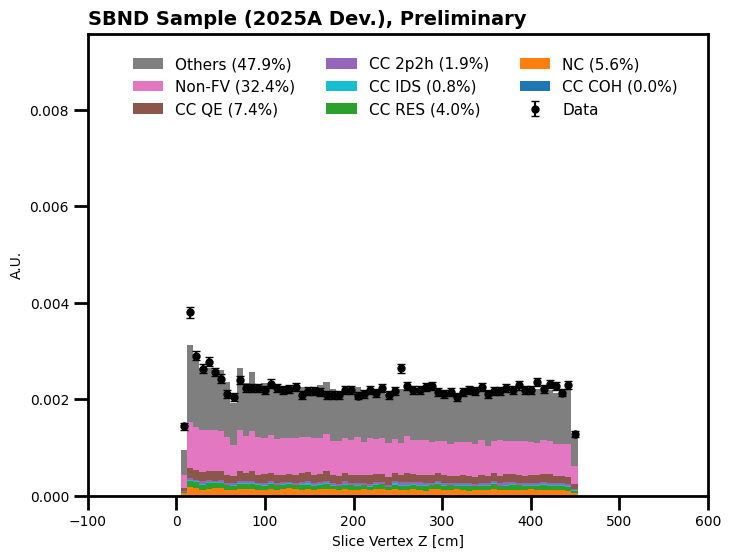

In [32]:
## Reco 4) n(pfp track with len > 4cm) = 2 
n_pfp_trk_4cm_cut_mc = (mc_matchdf.rec.n_trk_4cm > 1)
n_pfp_trk_4cm_cut_data = (data_evt_df.rec.n_trk_4cm > 1)

mc_matchdf = mc_matchdf[n_pfp_trk_4cm_cut_mc]
data_evt_df = data_evt_df[n_pfp_trk_4cm_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "n_pfp_trk_4cm")

1.9961502029181986
1.0


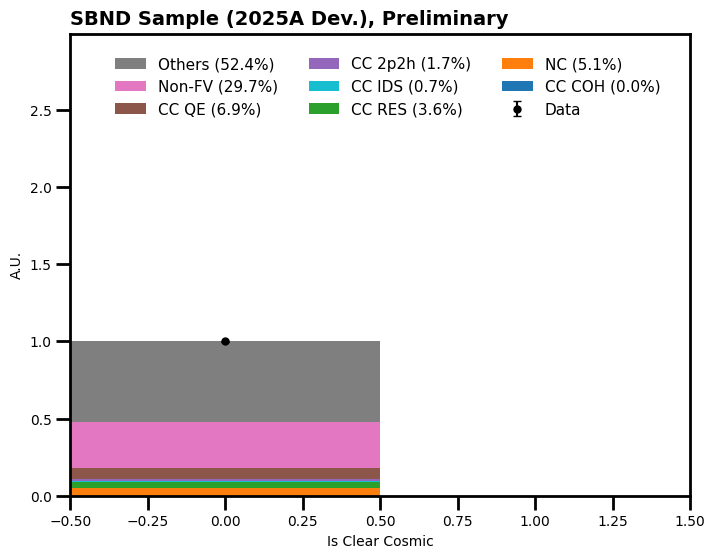

7.236401873625875
20.000000000000007


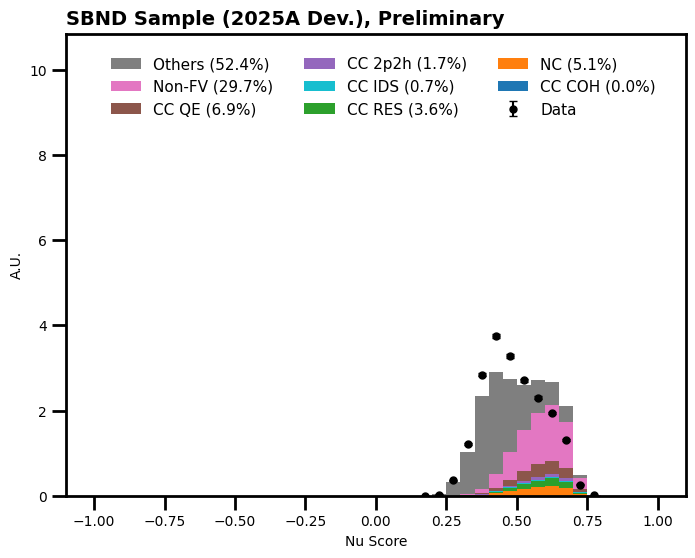

0.006055681564715118
0.16666666666666669


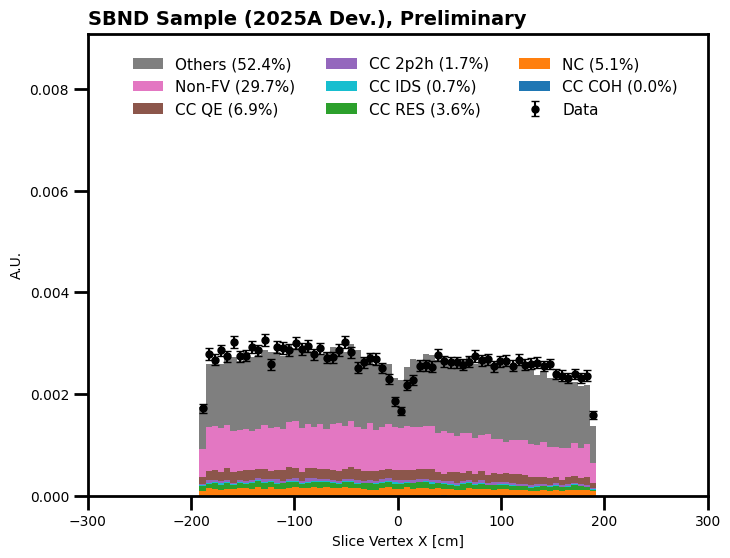

0.006565511727542126
0.16666666666666669


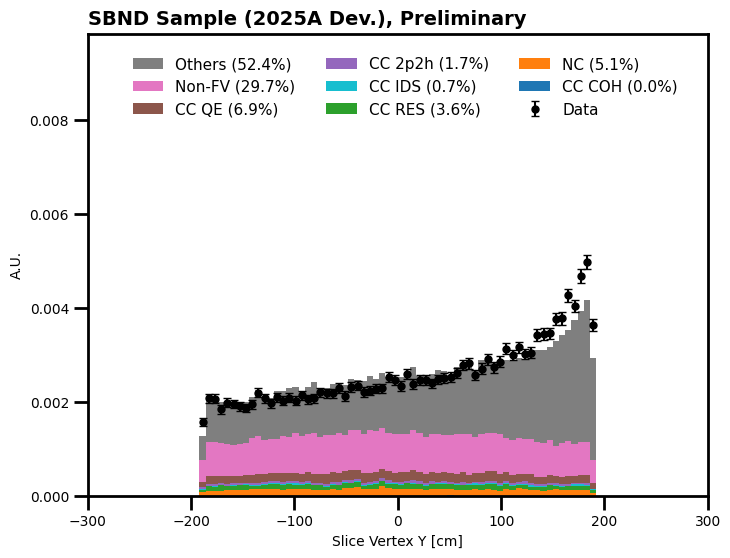

0.00631411414319358
0.14285714285714285


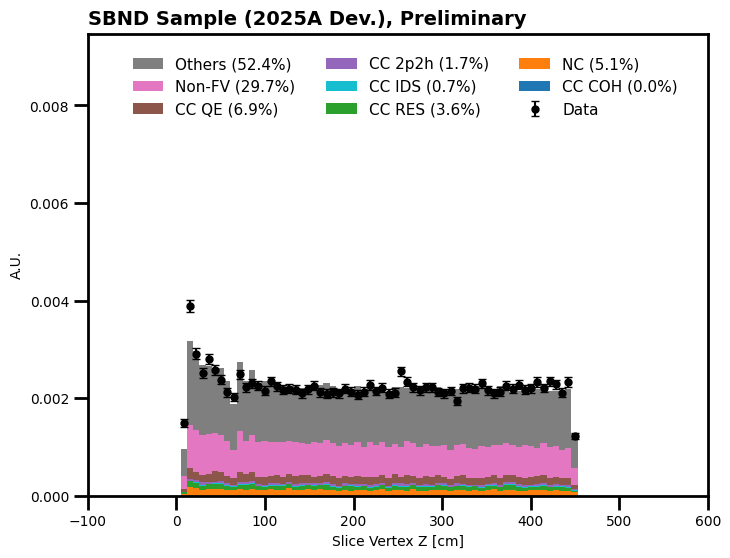

In [33]:
## Reco 5) n(pfp track with len > 4cm && vtx dist < 6 cm) = 2 
n_trk_vtx_dist_6cm_cut_mc = (mc_matchdf.rec.n_trk_vtx_dist_6cm == 2)
n_trk_vtx_dist_6cm_cut_data = (data_evt_df.rec.n_trk_vtx_dist_6cm == 2)

mc_matchdf = mc_matchdf[n_trk_vtx_dist_6cm_cut_mc]
data_evt_df = data_evt_df[n_trk_vtx_dist_6cm_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "n_pfp_trk_4cm")

In [34]:
data_evt_df

slc              \
                                             is_clear_cosmic      vertex   
                                                                       x   
                                                                           
                                                                           
                                                                           
entry rec.slc..index rec.slc.reco.pfp..index                               
0     0              1                                     0  -99.640762   
                     2                                     0  -99.640762   
6     0              2                                     0 -179.547974   
                     3                                     0 -179.547974   
      3              1                                     0  -74.385727   
..                                                       ...         ...   
94041 1              2                                     0  -99.576225   
94042 1              1                                     0  -38.658901   
                     2                                     0  -38.658901   
94043 0              1                                     0  164.507339   
                     2                                     0  164.507339   

                                                                           \
                                                                     self   
                                                       y           z        
                                                                            
                                                                            
                                                                            
entry rec.slc..index rec.slc.reco.pfp..index                                
0     0              1                        159.892181  190.661697   59   
                     2                        159.892181  190.661697   59   
6     0              2                         91.183098  370.475006   91   
                     3                         91.183098  370.475006   91   
      3              1                        165.016846  383.890533   92   
..                                                   ...         ...  ...   
94041 1              2                         41.309906  262.277832   60   
94042 1              1                        112.427574  308.350922   29   
                     2                        112.427574  308.350922   29   
94043 0              1                        111.723221  399.746857   33   
                     2                        111.723221  399.746857   33   

                                                                       \
                                             tmatch          producer   
                                                eff pur  idx            
                                                                        
                                                                        
                                                                        
entry rec.slc..index rec.slc.reco.pfp..index                            
0     0              1                          NaN NaN -999        0   
                     2                          NaN NaN -999        0   
6     0              2                          NaN NaN -999        0   
                     3                          NaN NaN -999        0   
      3              1                          NaN NaN -999        0   
..                                              ...  ..  ...      ...   
94041 1              2                          NaN NaN -999        0   
94042 1              1                          NaN NaN -999        0   
                     2                          NaN NaN -999        0   
94043 0              1                          NaN NaN -999        0   
                     2                          NaN NaN -999

In [35]:
def opening_angle(n_trk_vtx_dist, dir_x, dir_y, dir_z, trk_vtx_dist_pass):
    #print("opening_angle")                                                                                                                                                                                                                                                     
    if n_trk_vtx_dist != 2:
        return -999.
    dir_x = dir_x[trk_vtx_dist_pass]
    dir_y = dir_y[trk_vtx_dist_pass]
    dir_z = dir_z[trk_vtx_dist_pass]
    if(dir_x.size != 2):
        print("error, dir_x.len != 2")
        return -888.

    this_cos_theta = dir_x.iloc[0] * dir_x.iloc[1] + dir_y.iloc[0] * dir_y.iloc[1] + dir_z.iloc[0] * dir_z.iloc[1]
    return this_cos_theta

def measure_opening_angle(group):
    n_trk_vtx_dist = group[('rec', 'n_trk_vtx_dist_6cm', '', '', '', '')].iloc[0]
    dir_x = group[('pfp', 'trk', 'dir', 'x', '', '')]
    dir_y = group[('pfp', 'trk', 'dir', 'y', '', '')]
    dir_z = group[('pfp', 'trk', 'dir', 'z', '', '')]
    trk_vtx_dist_pass = group[('pfp', 'trk', 'pass_vtx_dist', '', '', '')]

    # Call reco_t function                                                                                                                                                                                                                                                      
    return opening_angle(n_trk_vtx_dist, dir_x, dir_y, dir_z, trk_vtx_dist_pass)

def add_two_trk_opening_angle_col(df):
    opening_angle_series = df.groupby(['entry', 'rec.slc..index']).apply(measure_opening_angle)
    opening_angle_df = opening_angle_series.to_frame(name='reco_opening_angle')
    opening_angle_df.index.set_names(['entry', 'rec.slc..index'], inplace=True)
    df[('rec', 'opening_angle', '', '', '', '')] = opening_angle_df

In [36]:
add_two_trk_opening_angle_col(data_evt_df)
add_two_trk_opening_angle_col(mc_matchdf)

In [37]:
data_evt_df

slc              \
                                             is_clear_cosmic      vertex   
                                                                       x   
                                                                           
                                                                           
                                                                           
entry rec.slc..index rec.slc.reco.pfp..index                               
0     0              1                                     0  -99.640762   
                     2                                     0  -99.640762   
6     0              2                                     0 -179.547974   
                     3                                     0 -179.547974   
      3              1                                     0  -74.385727   
..                                                       ...         ...   
94041 1              2                                     0  -99.576225   
94042 1              1                                     0  -38.658901   
                     2                                     0  -38.658901   
94043 0              1                                     0  164.507339   
                     2                                     0  164.507339   

                                                                           \
                                                                     self   
                                                       y           z        
                                                                            
                                                                            
                                                                            
entry rec.slc..index rec.slc.reco.pfp..index                                
0     0              1                        159.892181  190.661697   59   
                     2                        159.892181  190.661697   59   
6     0              2                         91.183098  370.475006   91   
                     3                         91.183098  370.475006   91   
      3              1                        165.016846  383.890533   92   
..                                                   ...         ...  ...   
94041 1              2                         41.309906  262.277832   60   
94042 1              1                        112.427574  308.350922   29   
                     2                        112.427574  308.350922   29   
94043 0              1                        111.723221  399.746857   33   
                     2                        111.723221  399.746857   33   

                                                                       \
                                             tmatch          producer   
                                                eff pur  idx            
                                                                        
                                                                        
                                                                        
entry rec.slc..index rec.slc.reco.pfp..index                            
0     0              1                          NaN NaN -999        0   
                     2                          NaN NaN -999        0   
6     0              2                          NaN NaN -999        0   
                     3                          NaN NaN -999        0   
      3              1                          NaN NaN -999        0   
..                                              ...  ..  ...      ...   
94041 1              2                          NaN NaN -999        0   
94042 1              1                          NaN NaN -999        0   
                     2                          NaN NaN -999        0   
94043 0              1                          NaN NaN -999        0   
                     2                          NaN NaN -999

In [38]:
mc_matchdf

slc              \
                                              is_clear_cosmic      vertex   
                                                                        x   
                                                                            
                                                                            
                                                                            
entry  rec.slc..index rec.slc.reco.pfp..index                               
2      1              0                                     0 -126.616188   
                      1                                     0 -126.616188   
5      3              0                                     0    7.956848   
                      1                                     0    7.956848   
9      1              1                                     0 -174.264984   
..                                                        ...         ...   
266145 2              2                                     0  -78.332062   
                      3                                     0  -78.332062   
                      4                                     0  -78.332062   
266147 0              0                                     0  163.217896   
                      1                                     0  163.217896   

                                                                           \
                                                                     self   
                                                       y           z        
                                                                            
                                                                            
                                                                            
entry  rec.slc..index rec.slc.reco.pfp..index                               
2      1              0                        21.935757  225.116440   51   
                      1                        21.935757  225.116440   51   
5      3              0                        14.170064  286.028381  260   
                      1                        14.170064  286.028381  260   
9      1              1                       -29.533756  421.355255   37   
..                                                   ...         ...  ...   
266145 2              2                        90.585907  246.162323   92   
                      3                        90.585907  246.162323   92   
                      4                        90.585907  246.162323   92   
266147 0              0                        51.003811  151.829056   45   
                      1                        51.003811  151.829056   45   

                                                                        \
                                                 tmatch                  
                                                    eff       pur  idx   
                                                                         
                                                                         
                                                                         
entry  rec.slc..index rec.slc.reco.pfp..index                            
2      1              0                        0.800736  0.995006    0   
                      1                        0.800736  0.995006    0   
5      3              0                        0.702217  0.929486    0   
                      1                        0.702217  0.929486    0   
9      1              1                        0.876271  0.975457    2   
..                                                  ...       ...  ...   
266145 2              2                             NaN       NaN -999   
                      3                             NaN       NaN -999   
                      4                             NaN       NaN -999   
266147 0              0                             NaN       NaN -999   
                      1   

5.641734233647048
49.999999999999986


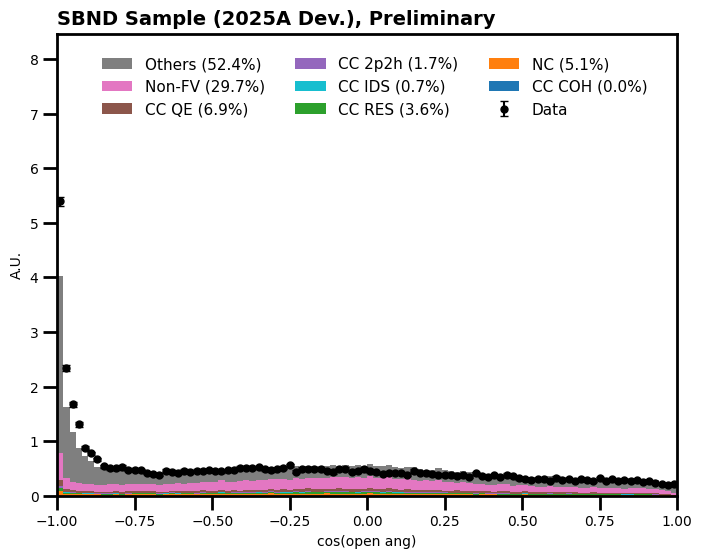

In [39]:
opening_ang_col = ('rec', 'opening_angle', '', '', '', '')
draw_mc_data_shape_comp_per_slc(mc_matchdf, data_evt_df, opening_ang_col, "cos(open ang)", "A.U.", -1, 1, 100, "_opening_ang")

2.134214522363335
1.0


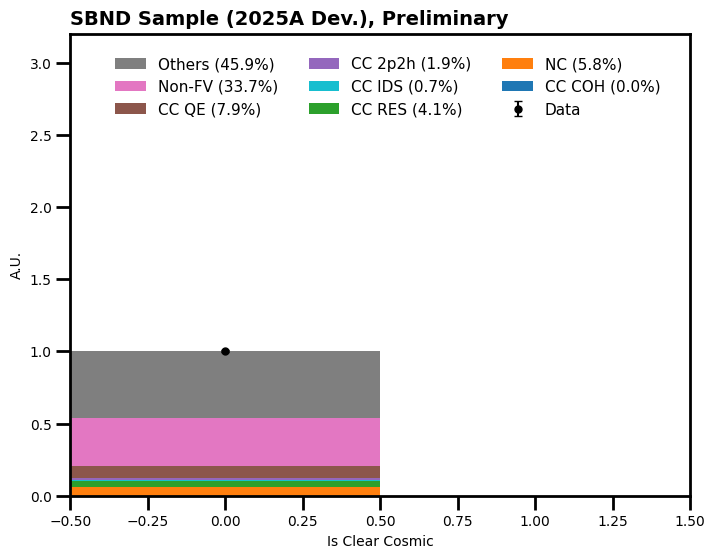

8.676605926744003
20.000000000000007


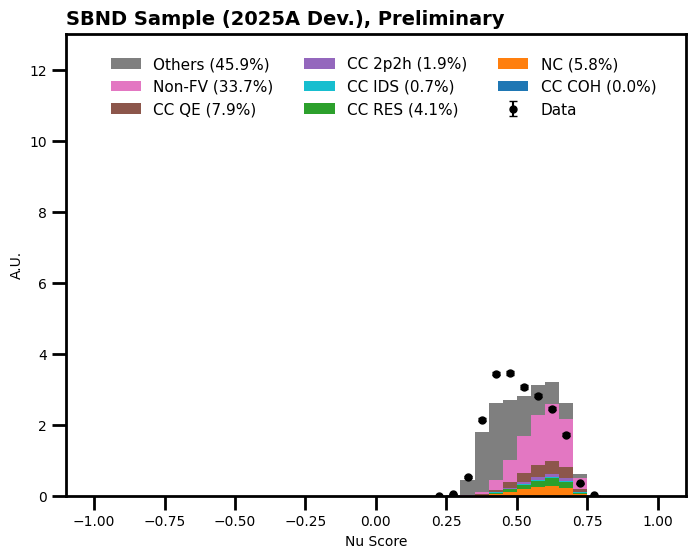

0.0065916620651573716
0.16666666666666663


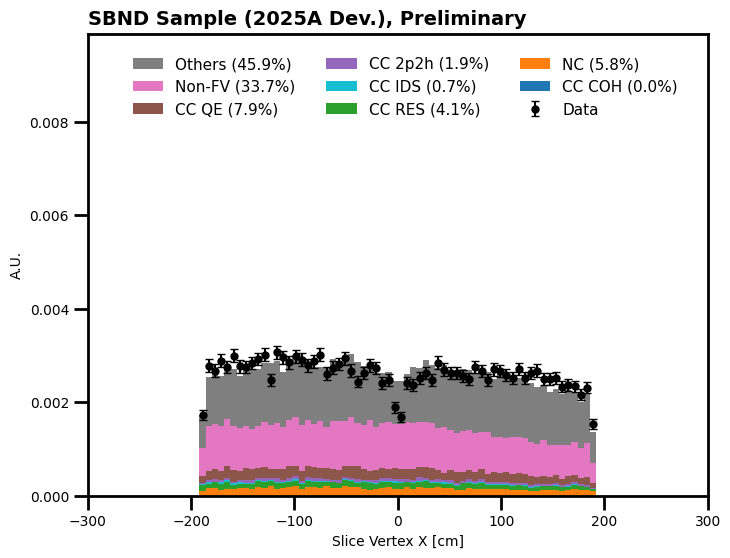

0.006436361126449475
0.16666666666666669


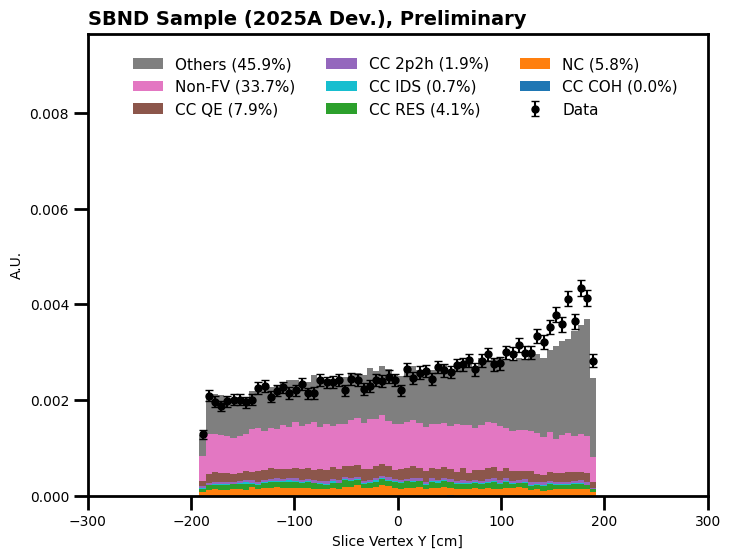

0.006018116799453077
0.14285714285714285


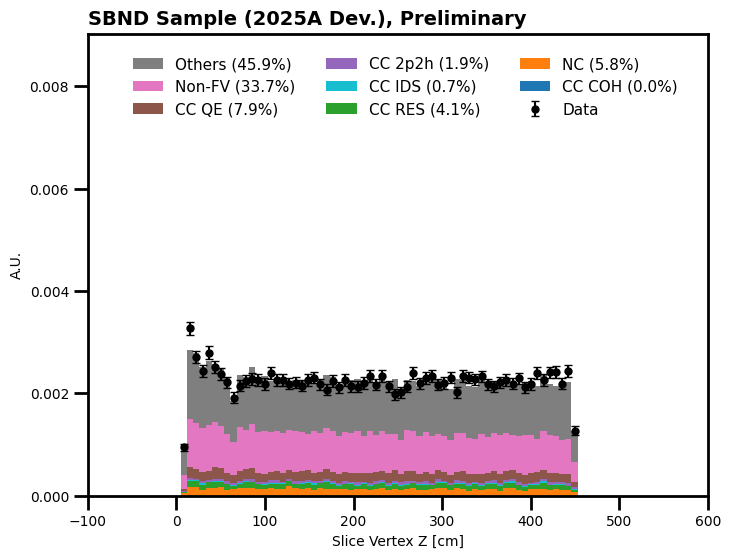

In [40]:
## Reco 6) two track opening angle > -0.75
open_ang_cut_mc = (mc_matchdf.rec.opening_angle > -0.75)
open_ang_cut_data = (data_evt_df.rec.opening_angle > -0.75)

mc_matchdf = mc_matchdf[open_ang_cut_mc]
data_evt_df = data_evt_df[open_ang_cut_data]

draw_reco_valid_plots(mc_matchdf, data_evt_df, "open_angle")

1.757776550708631
50.0


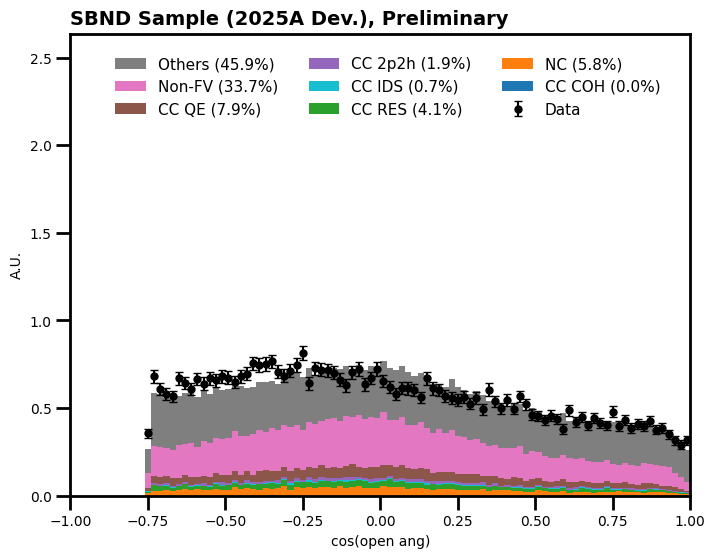

In [41]:
draw_mc_data_shape_comp_per_slc(mc_matchdf, data_evt_df, opening_ang_col, "cos(open ang)", "A.U.", -1, 1, 100, "_opening_ang")